Cell 1. Imports

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
from music21 import converter
import matplotlib.pyplot as plt
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
german_stopwords = set(stopwords.words('german'))
import warnings
warnings.filterwarnings('ignore')

print('Imports OK')
print(f'German stopwords: {len(german_stopwords)}')

Imports OK
German stopwords: 232


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\polyx\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Cell 2. Paths

In [ ]:
output_dir = Path(r'.\dataset') #EDIT THIS

df_meta = pd.read_csv(output_dir / 'metadata.csv')
df_meta['composer'] = df_meta['composer'].str.replace(
    'Johannes Brahms (1833-1897)', 'Johannes Brahms', regex=False
)
df_meta = df_meta[df_meta['composer'].isin([
    'Franz Schubert', 'Johannes Brahms', 'Robert Schumann'
])]

df_lyrics = pd.read_csv(output_dir / 'lyrics.csv')

print(df_meta.groupby('composer').size())
print(f'Total: {len(df_meta)}')

composer
Franz Schubert      86
Johannes Brahms    110
Robert Schumann     71
dtype: int64
Total: 267


Cell 3. Word-pitch alignment function

In [22]:
def get_word_pitch_pairs(score):
    pairs = []
    voice_part = score.parts[0]
    measures = list(voice_part.getElementsByClass('Measure'))
    
    current_word_syllables = []
    current_word_midi = []
    current_abs_offset = 0.0

    for measure in measures: 
        measure_offset = float(measure.offset)

        for note in measure.flatten().notes:
            if hasattr(note, 'pitch') and note.lyrics:
                abs_offset = measure_offset + float(note.offset)
                
                for lyric in note.lyrics:
                    if not lyric.text:
                        continue
                    
                    if lyric.syllabic == 'single':
                        pairs.append({
                            'word':       lyric.text,
                            'midi':       note.pitch.midi,
                            'offset':     float(note.offset),
                            'abs_offset': abs_offset
                        })
                    elif lyric.syllabic == 'begin':
                        current_word_syllables = [lyric.text]
                        current_word_midi = [note.pitch.midi]
                        current_abs_offset = abs_offset
                    elif lyric.syllabic == 'middle':
                        current_word_syllables.append(lyric.text)
                        current_word_midi.append(note.pitch.midi)
                    elif lyric.syllabic == 'end':
                        current_word_syllables.append(lyric.text)
                        current_word_midi.append(note.pitch.midi)
                        pairs.append({
                            'word':       ''.join(current_word_syllables),
                            'midi':       max(current_word_midi),
                            'offset':     float(note.offset),
                            'abs_offset': current_abs_offset
                        })
                        current_word_syllables = []
                        current_word_midi = []
    
    return pairs

print ('Word-pitch pair defined')

Word-pitch pair defined


In [23]:
# Test
pairs = get_word_pitch_pairs(s)
print(f"Word-pitch pairs: {len(pairs)}")
for p in pairs[:10]:
    print(f"'{p['word']}' → MIDI {p['midi']}")

Word-pitch pairs: 25
'1. Maria,' → MIDI 75
'wahre' → MIDI 75
'Himmelsfreud’,' → MIDI 70
'der' → MIDI 72
'Welt' → MIDI 70
'Ergötzlichkeit!' → MIDI 72
'Wer' → MIDI 63
'wollt’' → MIDI 63
'dich' → MIDI 63
'nicht' → MIDI 63


In [24]:
# Extract word-pitch pairs for all corpus
all_pairs = []

for idx, row in df_meta.iterrows():
    try:
        s = converter.parse(str(row['filepath']))
        pairs = get_word_pitch_pairs(s)
        for p in pairs:
            p['composer'] = row['composer']
            p['filename'] = row['filename']
        all_pairs.extend(pairs)
    except Exception as e:
        continue
    
    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(df_meta)}...")

df_pairs = pd.DataFrame(all_pairs)
df_pairs.to_csv(output_dir / 'word_pitch_pairs.csv', index=False)

print(f"\nDone! {len(df_pairs)} word-pitch pairs")
print(df_pairs.groupby('composer').size())

Processed 20/267...
Processed 40/267...
Processed 60/267...
Processed 80/267...
Processed 100/267...
Processed 120/267...
Processed 140/267...
Processed 160/267...
Processed 180/267...
Processed 200/267...
Processed 220/267...
Processed 240/267...
Processed 260/267...

Done! 26550 word-pitch pairs
composer
Franz Schubert     11011
Johannes Brahms     9869
Robert Schumann     5670
dtype: int64


In [25]:
# Cell 4: Clean word-pitch pairs
df_pairs['word_clean'] = df_pairs['word'].apply(
    lambda w: re.sub(r'[^a-zA-ZäöüÄÖÜß]', '', w).lower()
)

df_clean = df_pairs[
    (df_pairs['word_clean'].str.len() >= 3) &
    (~df_pairs['word_clean'].isin(german_stopwords))
].copy()

df_clean = df_clean[df_clean['word_clean'].str.match(r'^[a-zA-ZäöüÄÖÜß]+$')]
df_clean = df_clean[~df_clean['word_clean'].str.endswith(('sche', 'che', 'let', 'hig'))] #defining these because of issue in Schubert text

print(f"Original pairs: {len(df_pairs)}")
print(f"After cleaning: {len(df_clean)}")

Original pairs: 26550
After cleaning: 13163


Cell 5. Analysis

In [ ]:
# Cell 5: Analysis — mean pitch per composer
print("=== MEAN PITCH PER COMPOSER ===\n")
print(df_clean.groupby('composer')['midi'].describe().round(2))

#Top words at HIGH pitch per composer
print("\n=== TOP WORDS AT HIGH PITCH (>75 MIDI) ===\n")
high_pitch = df_clean[df_clean['midi'] > 75]
for composer in ['Franz Schubert', 'Johannes Brahms', 'Robert Schumann']:
    words = high_pitch[high_pitch['composer']==composer]['word_clean'].value_counts().head(10)
    print(f"{composer}:")
    print(f"  {', '.join(words.index.tolist())}")
    print()

# Top words at LOW pitch per composer
print("=== TOP WORDS AT LOW PITCH (<60 MIDI) ===\n")
low_pitch = df_clean[df_clean['midi'] < 60]
for composer in ['Franz Schubert', 'Johannes Brahms', 'Robert Schumann']:
    words = low_pitch[low_pitch['composer']==composer]['word_clean'].value_counts().head(10)
    print(f"{composer}:")
    print(f"  {', '.join(words.index.tolist())}")
    print()

=== MEAN PITCH PER COMPOSER ===

                  count   mean   std   min   25%   50%   75%   max
composer                                                          
Franz Schubert   5489.0  70.97  4.68  45.0  69.0  72.0  74.0  81.0
Johannes Brahms  4862.0  71.39  4.91  43.0  69.0  72.0  75.0  81.0
Robert Schumann  2812.0  70.43  3.88  57.0  68.0  71.0  73.0  81.0

=== TOP WORDS AT HIGH PITCH (>75 MIDI) ===

Franz Schubert:
  herz, ruh, tränen, gern, liebst, süsse, maria, bächlein, reissend, träume

Johannes Brahms:
  liebe, herz, seele, gar, liebsten, schönen, mehr, ach, himmel, lieb

Robert Schumann:
  weh, liebe, jemand, ferne, ganz, lied, wildniss, wüsstens, drein, flüstern

=== TOP WORDS AT LOW PITCH (<60 MIDI) ===

Franz Schubert:
  rauhen, reicht, audige, helle, dach, duft, ben, eibus, bet, ner

Johannes Brahms:
  tod, wohl, wäre, stirbt, odem, mensch, sonne, tust, hätte, wann

Robert Schumann:
  sei, tag, jagt, alte, wohl, schar, wach, munter, wohin, wild



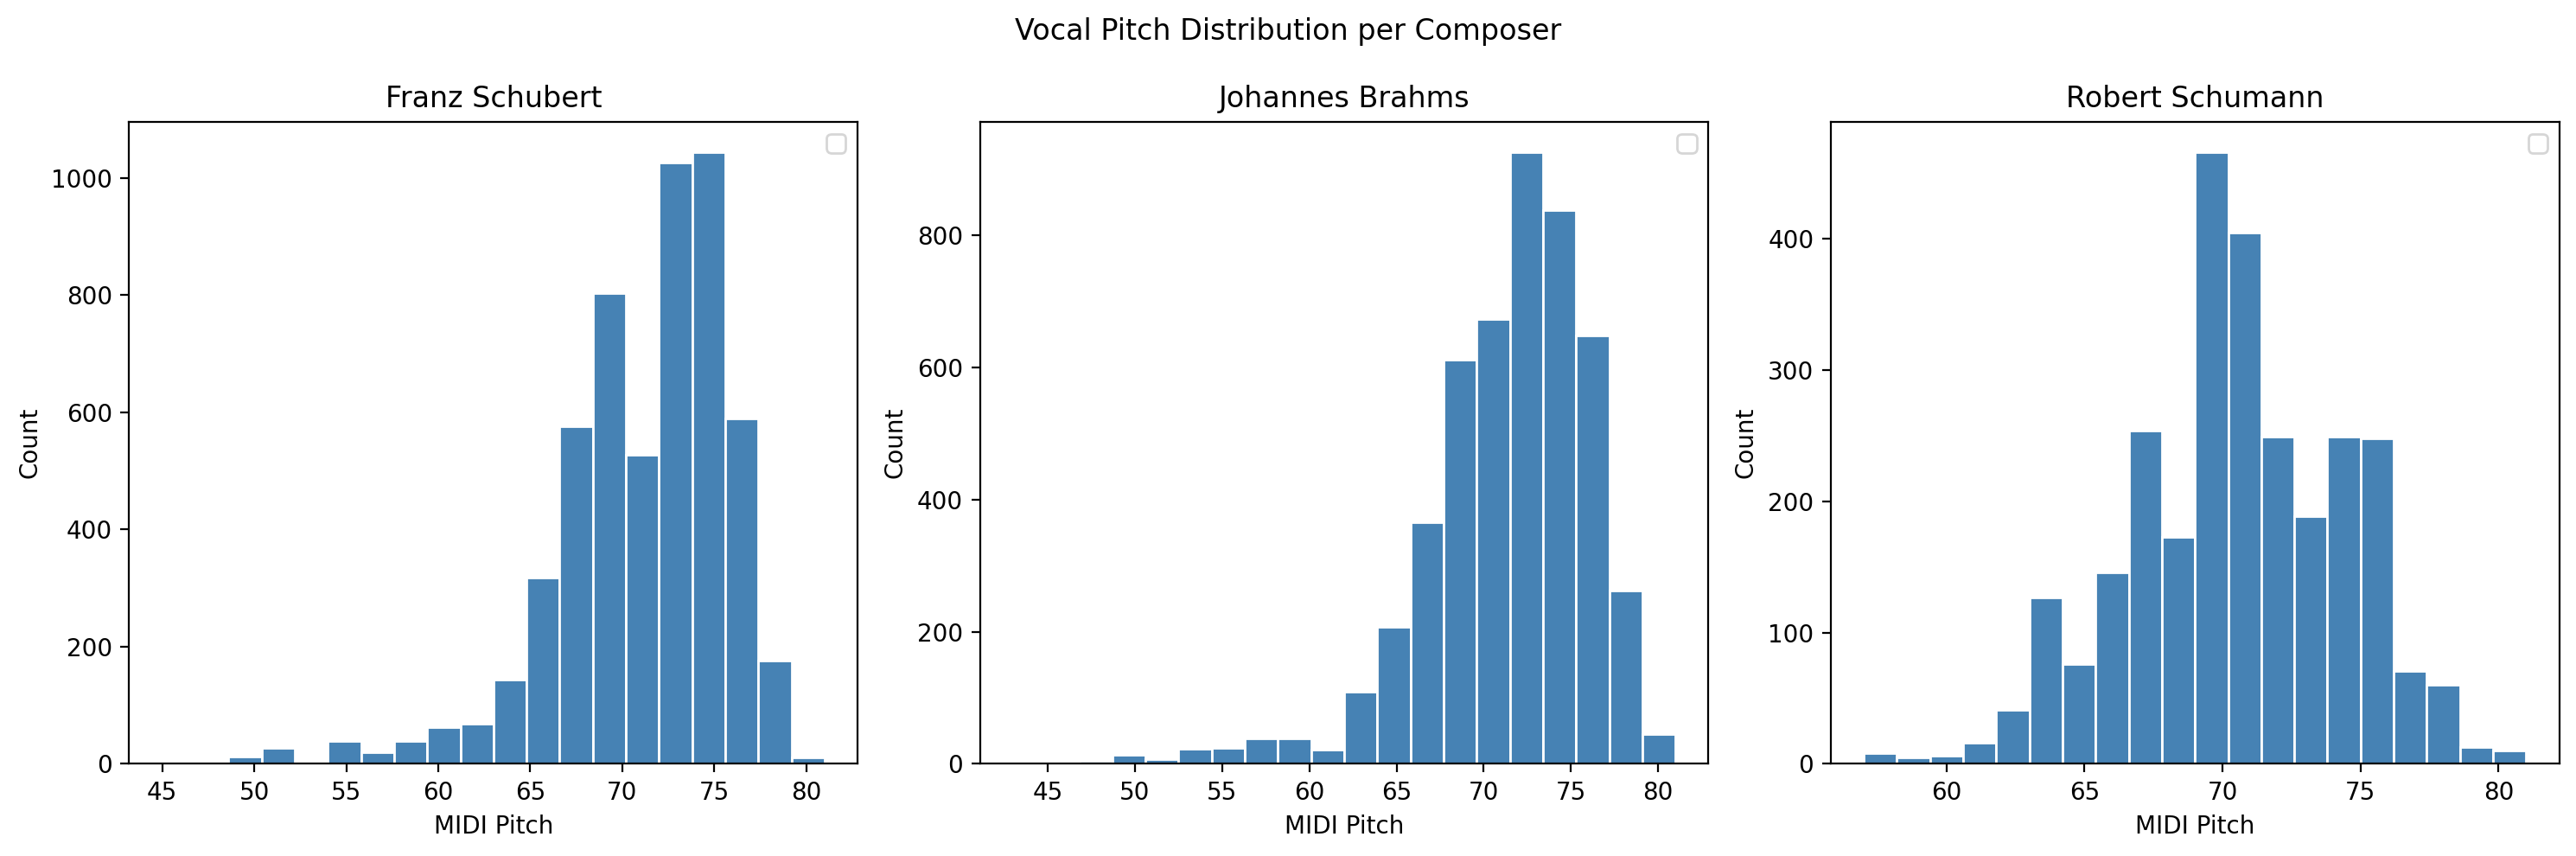

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, composer in zip(axes, ['Franz Schubert', 'Johannes Brahms', 'Robert Schumann']):
    data = df_clean[df_clean['composer'] == composer]['midi']
    ax.hist(data, bins=20, color='steelblue', edgecolor='white')
    ax.set_title(composer)
    ax.set_xlabel('MIDI Pitch')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Vocal Pitch Distribution per Composer')
plt.tight_layout()
plt.show()

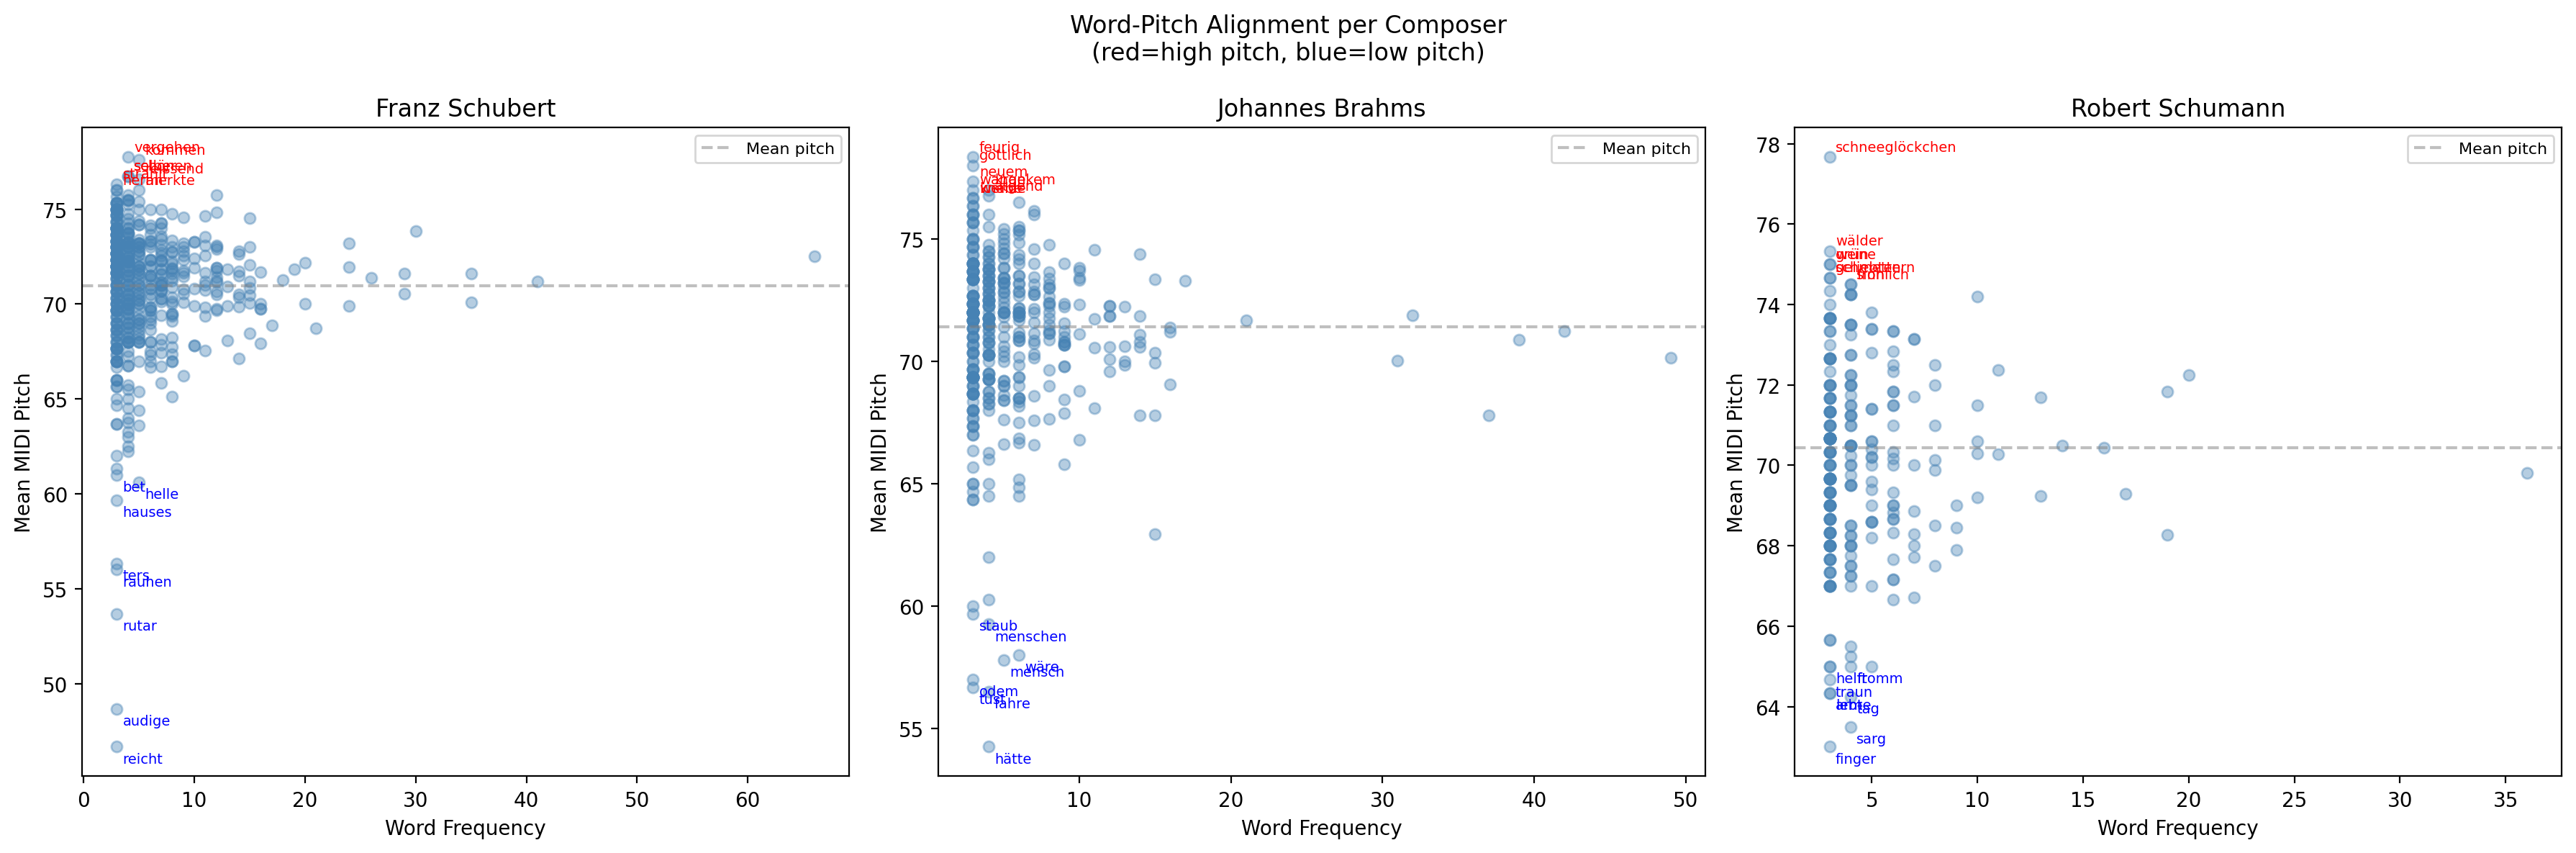

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

composers = ['Franz Schubert', 'Johannes Brahms', 'Robert Schumann']

for ax, composer in zip(axes, composers):
    data = df_clean[df_clean['composer'] == composer]
    
    # Scatter plot: x=word frequency, y=mean pitch
    word_stats = data.groupby('word_clean')['midi'].agg(['mean', 'count']).reset_index()
    word_stats = word_stats[word_stats['count'] >= 3]  # minimum 3 appearances
    
    ax.scatter(word_stats['count'], word_stats['mean'], 
               alpha=0.4, color='steelblue', s=30)
    
    # Label top high pitch words
    top_high = word_stats.nlargest(8, 'mean')
    for _, row in top_high.iterrows():
        ax.annotate(row['word_clean'], 
                   (row['count'], row['mean']),
                   fontsize=7, color='red',
                   xytext=(3, 3), textcoords='offset points')
    
    # Label top low pitch words
    top_low = word_stats.nsmallest(8, 'mean')
    for _, row in top_low.iterrows():
        ax.annotate(row['word_clean'], 
                   (row['count'], row['mean']),
                   fontsize=7, color='blue',
                   xytext=(3, -8), textcoords='offset points')
    
    ax.set_title(composer)
    ax.set_xlabel('Word Frequency')
    ax.set_ylabel('Mean MIDI Pitch')
    ax.axhline(data['midi'].mean(), color='gray', 
               linestyle='--', alpha=0.5, label='Mean pitch')
    ax.legend(fontsize=8)

plt.suptitle('Word-Pitch Alignment per Composer\n(red=high pitch, blue=low pitch)', 
             fontsize=12)
plt.tight_layout()
plt.show()

Word-Tension Alignment

In [ ]:
def get_word_tension_pairs(score):
    """For each word (word, midi, tonal_tension) in the same offset"""
    pairs = []
    voice_part = score.parts[0]
    measures = list(voice_part.getElementsByClass('Measure'))
    
    # tonal tension per beat (absolute offset)
    tension_map = {}  # abs_offset → tension value
    
    for measure in measures:
        measure_offset = float(measure.offset)
        beat_unit = get_beat_unit(measure)
        dur = measure.duration.quarterLength
        
        beat_pitches = {}
        offset = 0.0
        while offset < dur:
            beat_pitches[round(offset, 4)] = []
            offset = round(offset + beat_unit, 4)
        
        for part in score.parts:
            part_measures = list(part.getElementsByClass('Measure'))
            m_idx = measures.index(measure)
            if m_idx >= len(part_measures):
                continue
            for el in part_measures[m_idx].flatten().notes:
                beat = round(float(el.offset) / beat_unit) * beat_unit
                beat = round(beat, 4)
                if beat not in beat_pitches:
                    continue
                if hasattr(el, 'pitches'):
                    beat_pitches[beat].extend([p.midi for p in el.pitches])
                else:
                    beat_pitches[beat].append(el.pitch.midi)
        
        for beat_offset, pitches in beat_pitches.items():
            abs_off = round(measure_offset + beat_offset, 4)
            if len(pitches) < 2:
                tension_map[abs_off] = 0.0
            else:
                coords = np.array([pitch_to_spiral(p) for p in pitches])
                centroid = coords.mean(axis=0)
                distances = np.linalg.norm(coords - centroid, axis=1)
                tension_map[abs_off] = float(distances.mean())
    
    # Match each word with tension
    current_word_syllables = []
    current_word_midi = []
    current_abs_offset = 0.0
    
    for measure in measures:
        measure_offset = float(measure.offset)
        beat_unit = get_beat_unit(measure)
        
        for note in measure.flatten().notes:
            if hasattr(note, 'pitch') and note.lyrics:
                abs_offset = round(measure_offset + float(note.offset), 4)
                
                # find closest beat
                beat = round(float(note.offset) / beat_unit) * beat_unit
                beat_abs = round(measure_offset + beat, 4)
                tension = tension_map.get(beat_abs, 0.0)
                
                for lyric in note.lyrics:
                    if not lyric.text:
                        continue
                    if lyric.syllabic == 'single':
                        pairs.append({
                            'word':    lyric.text,
                            'midi':    note.pitch.midi,
                            'tension': tension
                        })
                    elif lyric.syllabic == 'begin':
                        current_word_syllables = [lyric.text]
                        current_word_midi = [note.pitch.midi]
                        current_abs_offset = tension
                    elif lyric.syllabic == 'middle':
                        current_word_syllables.append(lyric.text)
                        current_word_midi.append(note.pitch.midi)
                    elif lyric.syllabic == 'end':
                        current_word_syllables.append(lyric.text)
                        current_word_midi.append(note.pitch.midi)
                        pairs.append({
                            'word':    ''.join(current_word_syllables),
                            'midi':    max(current_word_midi),
                            'tension': current_abs_offset
                        })
                        current_word_syllables = []
                        current_word_midi = []
    
    return pairs


In [37]:
def pitch_to_spiral(midi_pitch: int) -> np.ndarray:
    r, h = 1.0, 0.1
    k = midi_pitch % 12
    angle = k * (2 * np.pi / 12) * (7/12)
    x = r * np.sin(angle)
    y = r * np.cos(angle)
    z = (midi_pitch // 12) * h
    return np.array([x, y, z])

def get_beat_unit(measure):
    ts = measure.getElementsByClass('TimeSignature')
    if not ts:
        ts = measure.getContextByClass('TimeSignature')
        if not ts:
            return 1.0
        time_sig = ts
    else:
        time_sig = ts[0]
    if time_sig.denominator == 8:
        return 0.5
    else:
        return 1.0

print('Helper functions defined')

Helper functions defined


In [38]:
# Test
s = converter.parse(str(mxl_files[0]))
pairs = get_word_tension_pairs(s)
print(f"Word-tension pairs: {len(pairs)}")
for p in pairs[:10]:
    print(f"'{p['word']}' → tension={p['tension']:.3f}")

Word-tension pairs: 44
'Wie' → tension=0.044
'sich' → tension=0.044
'Rebenranken' → tension=0.044
'schwingen' → tension=0.044
'in' → tension=0.044
'der' → tension=0.044
'linden' → tension=0.044
'Lüfte' → tension=0.159
'Hauch,' → tension=0.159
'wie' → tension=0.835


In [ ]:
# Extract word-tension pairs for all corpus
all_tension_pairs = []

for idx, row in df_meta.iterrows():
    try:
        s = converter.parse(str(row['filepath']))
        pairs = get_word_tension_pairs(s)
        for p in pairs:
            p['composer'] = row['composer']
            p['filename'] = row['filename']
        all_tension_pairs.extend(pairs)
    except Exception as e:
        continue
    
    if (idx + 1) % 20 == 0:
        print(f"Processed {idx+1}/{len(df_meta)}...")

df_tension = pd.DataFrame(all_tension_pairs)
df_tension.to_csv(output_dir / 'word_tension_pairs.csv', index=False)

print(f"\nDone! {len(df_tension)} word-tension pairs")
print(df_tension.groupby('composer').size())

Processed 20/267...
Processed 40/267...
Processed 60/267...
Processed 80/267...
Processed 100/267...
Processed 120/267...
Processed 140/267...
Processed 160/267...
Processed 180/267...
Processed 200/267...
Processed 220/267...
Processed 240/267...
Processed 260/267...

Done! 26550 word-tension pairs
composer
Franz Schubert     11011
Johannes Brahms     9869
Robert Schumann     5670
dtype: int64


In [32]:
import re
from nltk.corpus import stopwords
german_stopwords = set(stopwords.words('german'))

# Clean
df_tension['word_clean'] = df_tension['word'].apply(
    lambda w: re.sub(r'[^a-zA-ZäöüÄÖÜß]', '', w).lower()
)

fragment_pattern = r'^(ben|ner|ber|gen|ten|den|ren|sen|len|hen|nen|men|tes|des|aus|ein|auf|bei|mit|von|zum|zur|vom|ins|dam)$'

df_tension_clean = df_tension[
    (df_tension['word_clean'].str.len() >= 3) &
    (~df_tension['word_clean'].isin(german_stopwords)) &
    (~df_tension['word_clean'].str.match(fragment_pattern))
].copy()

print(f"After cleaning: {len(df_tension_clean)}")

# Analysis — top words at HIGH tension per composer
print("\n=== TOP WORDS AT HIGH TENSION (>0.6) ===\n")
high_tension = df_tension_clean[df_tension_clean['tension'] > 0.6]
for composer in ['Franz Schubert', 'Johannes Brahms', 'Robert Schumann']:
    words = high_tension[high_tension['composer']==composer]['word_clean'].value_counts().head(8)
    print(f"{composer}:")
    print(f"  {', '.join(words.index.tolist())}")
    print()

# Top words at LOW tension per composer
print("=== TOP WORDS AT LOW TENSION (<0.2) ===\n")
low_tension = df_tension_clean[df_tension_clean['tension'] < 0.2]
for composer in ['Franz Schubert', 'Johannes Brahms', 'Robert Schumann']:
    words = low_tension[low_tension['composer']==composer]['word_clean'].value_counts().head(8)
    print(f"{composer}:")
    print(f"  {', '.join(words.index.tolist())}")
    print()

After cleaning: 13074

=== TOP WORDS AT HIGH TENSION (>0.6) ===

Franz Schubert:
  herz, ach, nacht, ruh, ade, wohl, gern, welt

Johannes Brahms:
  ach, nacht, wohl, herz, liebe, mehr, gehn, komm

Robert Schumann:
  herz, liebe, weh, wohl, himmel, lass, traum, blumen

=== TOP WORDS AT LOW TENSION (<0.2) ===

Franz Schubert:
  wer, wangen, gemeint, tränen, bald, spielt, haus, dach

Johannes Brahms:
  mehr, wohl, stehn, nacht, beide, hinber, ach, sprich

Robert Schumann:
  wohl, traum, geweinet, wachte, ach, occident, flüstern, grab



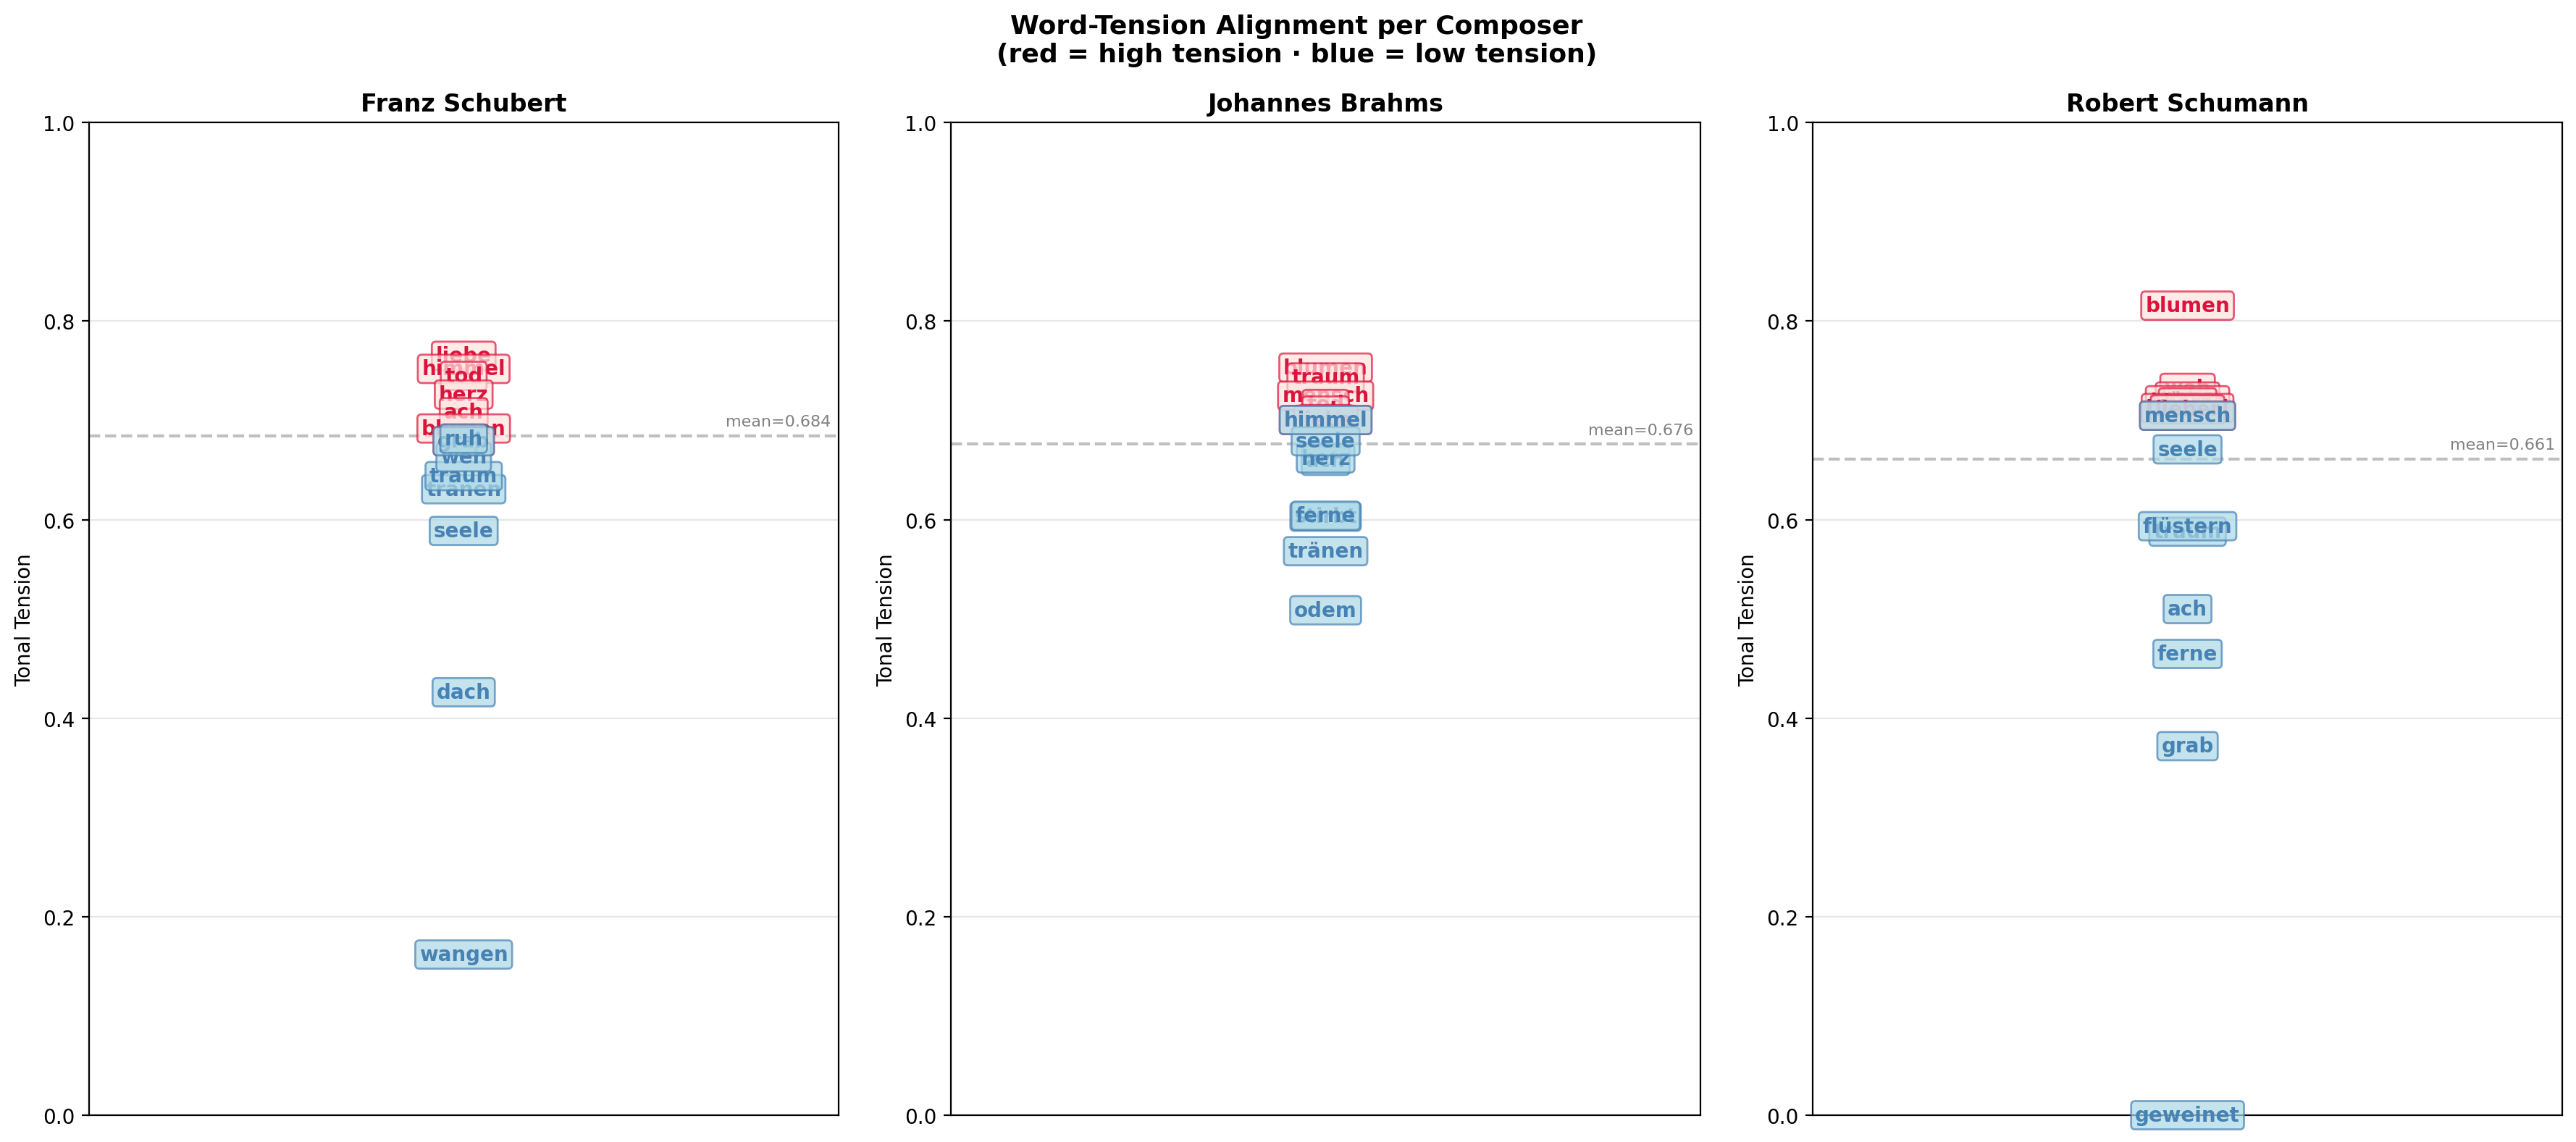

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
composers = ['Franz Schubert', 'Johannes Brahms', 'Robert Schumann']

exclude = {'gar', 'mehr', 'wohl', 'lass', 'gern', 'weit', 'voll',
           'ganz', 'eben', 'jetzt', 'schon', 'noch', 'immer', 'ach',
           'wann', 'tust', 'wäre', 'hätte', 'sei', 'gehn', 'stehn',
           'komm', 'sprich', 'bald', 'nacht', 'herz',
           'hinber', 'beide', 'wer', 'gemeint', 'spielt',
           'occident', 'wüsstens', 'drein', 'wildniss',
           'jemand', 'ganz', 'lied', 'ade', 'welt'}
keep_words = {'herz', 'ach', 'ruh', 'liebe', 'lieber', 'himmel', 
              'traum', 'blumen', 'tränen', 'tod', 'stirbt', 
              'mensch', 'odem', 'grab', 'geweinet', 'flüstern',
              'wangen', 'dach', 'weh', 'ferne', 'seele'}

for ax, composer in zip(axes, composers):
    data = df_tension_clean[
        (df_tension_clean['composer'] == composer) &
        (df_tension_clean['word_clean'].isin(keep_words))  
    ]

    word_stats = data.groupby('word_clean')['tension'].agg(['mean', 'count']).reset_index()
    word_stats = word_stats[word_stats['count'] >= 3]
    mean_tension = data['tension'].mean()
    
    top_high = word_stats.nlargest(8, 'mean')
    top_low  = word_stats.nsmallest(8, 'mean')
    
    for _, row in top_high.iterrows():
        ax.text(0.5, row['mean'], row['word_clean'],
                ha='center', va='center',
                fontsize=10, color='crimson', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='mistyrose',
                         edgecolor='crimson', alpha=0.7))
    
    for _, row in top_low.iterrows():
        ax.text(0.5, row['mean'], row['word_clean'],
                ha='center', va='center',
                fontsize=10, color='steelblue', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue',
                         edgecolor='steelblue', alpha=0.7))
    
    ax.axhline(mean_tension, color='gray', linestyle='--', alpha=0.5)
    ax.text(0.85, mean_tension + 0.01, f'mean={mean_tension:.3f}',
            fontsize=8, color='gray', transform=ax.get_yaxis_transform())
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(composer, fontsize=12, fontweight='bold')
    ax.set_ylabel('Tonal Tension')
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Word-Tension Alignment per Composer\n(red = high tension · blue = low tension)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('word_tension_alignment.png', dpi=300, bbox_inches='tight')
plt.show()